# Retail Sales Exploratory Data Analysis

## Project Objective

This notebook explores the expanded retail sales dataset containing 50,000 transactions.

The goals of this EDA are to:

- Understand the structure of the dataset
- Evaluate data quality
- Analyze customer and product behavior
- Identify sales patterns and trends
- Discover relationships that may be useful for machine learning

## Dataset Overview

The dataset contains retail transactions across multiple customers, products, stores, categories, and payment methods.

In [1]:
import pandas as pd
df = pd.read_csv("../retail_sales.csv")
df.head()

,sale_id,sale_date,customer_id,product,category,quantity,price,store_id,payment_method
0,10001,2025-05-28,C1616,Keyboard,Accessories,5,49.99,S005,Mobile Payment
1,10002,2024-08-06,C1284,Laptop,Computers,3,899.99,S001,Cash
2,10003,2025-10-19,C0297,Laptop,Computers,1,899.99,S003,Credit Card
3,10004,2024-07-09,C1438,Webcam,Electronics,5,79.99,S005,Cash
4,10005,2025-05-24,C1743,Webcam,Electronics,4,79.99,S004,Cash


## Dataset Structure

Before performing analysis, we inspect the size, columns, and data types of the dataset.

In [2]:
print("Dataset Shape:", df.shape)
print()
df.info()

Dataset Shape: (50000, 9)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sale_id         50000 non-null  int64  
 1   sale_date       50000 non-null  str    
 2   customer_id     50000 non-null  str    
 3   product         50000 non-null  str    
 4   category        50000 non-null  str    
 5   quantity        50000 non-null  int64  
 6   price           50000 non-null  float64
 7   store_id        50000 non-null  str    
 8   payment_method  50000 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 3.4 MB


## Descriptive Statistics

We examine the numerical columns to understand their distributions, ranges, and typical values.

In [3]:
df.describe()

,sale_id,quantity,price
count,50000.000000,50000.000000,50000.000000
mean,35000.500000,2.996200,159.602900
std,14433.901067,1.412185,250.763953
min,10001.000000,1.000000,14.990000
25%,22500.750000,2.000000,34.990000
50%,35000.500000,3.000000,49.990000
75%,47500.250000,4.000000,129.990000
max,60000.000000,5.000000,899.990000


## Feature Engineering

To support sales analysis, we create a `total_sales` feature by multiplying the quantity purchased by the unit price.

In [4]:
df["total_sales"] = df["quantity"] * df["price"]

df[["quantity", "price", "total_sales"]].head()

,quantity,price,total_sales
0,5,49.99,249.95
1,3,899.99,2699.97
2,1,899.99,899.99
3,5,79.99,399.95
4,4,79.99,319.96


In [5]:
total_revenue = df["total_sales"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $23,971,436.90


## Product Performance

We analyze total revenue by product to identify the strongest and weakest revenue-generating products.

In [6]:
product_revenue = (
    df.groupby("product")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

product
Laptop            13048955.01
Monitor            3795598.17
External SSD       1952449.80
Headphones         1484851.50
Webcam             1226086.72
Keyboard            727604.45
Laptop Stand        595531.08
USB Hub             539685.76
Wireless Mouse      375074.91
USB-C Cable         225599.50
Name: total_sales, dtype: float64

In [8]:
product_quantity = (
    df.groupby("product")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

product
USB Hub           15424
Webcam            15328
Monitor           15183
USB-C Cable       15050
External SSD      15020
Wireless Mouse    15009
Laptop Stand      14892
Headphones        14850
Keyboard          14555
Laptop            14499
Name: quantity, dtype: int64

## Product Revenue Visualization

We visualize total revenue by product to compare product performance and identify revenue concentration.

In [10]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 66.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 32.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 53.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------- ---------------------------- 2/7 [kiwisolver]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- -----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


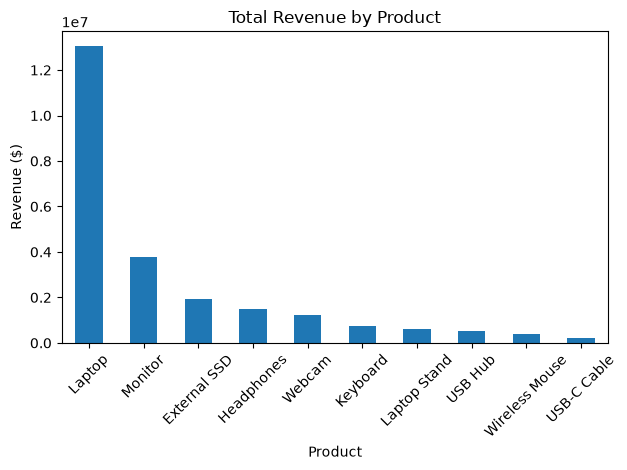

In [11]:
import matplotlib.pyplot as plt

product_revenue.plot(kind="bar")

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Product Sales Volume

We compare total units sold by product to determine whether the highest-revenue products are also the highest-selling products by volume.

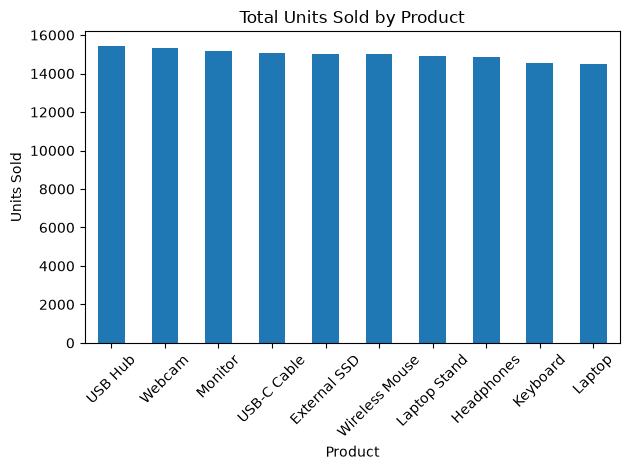

In [12]:
product_quantity.plot(kind="bar")

plt.title("Total Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Product sales volume is relatively balanced across all ten products, with each product selling approximately 14,500–15,400 units.

However, revenue is highly concentrated in higher-priced products. Laptops generated the most revenue despite having the lowest total unit sales.

This indicates that product price, rather than sales volume, is the primary driver of the revenue differences observed in this synthetic dataset.

## Sales Over Time

We analyze revenue over time to identify monthly sales patterns and trends within the retail dataset.

In [13]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

df["sale_date"].dtype

dtype('<M8[us]')

In [14]:
df["sale_month"] = df["sale_date"].dt.to_period("M")

df[["sale_date", "sale_month"]].head()

,sale_date,sale_month
0,2025-05-28,2025-05
1,2024-08-06,2024-08
2,2025-10-19,2025-10
3,2024-07-09,2024-07
4,2025-05-24,2025-05


In [15]:
monthly_revenue = (
    df.groupby("sale_month")["total_sales"]
    .sum()
    .sort_index()
)

monthly_revenue

sale_month
2024-01    1071336.79
2024-02     999248.81
2024-03     994708.50
2024-04    1009202.13
2024-05    1020191.35
2024-06     922203.60
2024-07     994176.47
2024-08     947260.11
2024-09     957193.82
2024-10    1015466.78
2024-11     915385.07
2024-12     994211.57
2025-01    1013610.77
2025-02     851002.85
2025-03    1093452.06
2025-04     987063.64
2025-05     960512.92
2025-06     946379.84
2025-07    1072871.43
2025-08     995656.52
2025-09     964184.94
2025-10    1108270.78
2025-11    1068445.02
2025-12    1069401.13
Freq: M, Name: total_sales, dtype: float64

### Monthly Revenue Trend

Monthly revenue is analyzed over time to identify trends, fluctuations, and potential seasonal patterns.

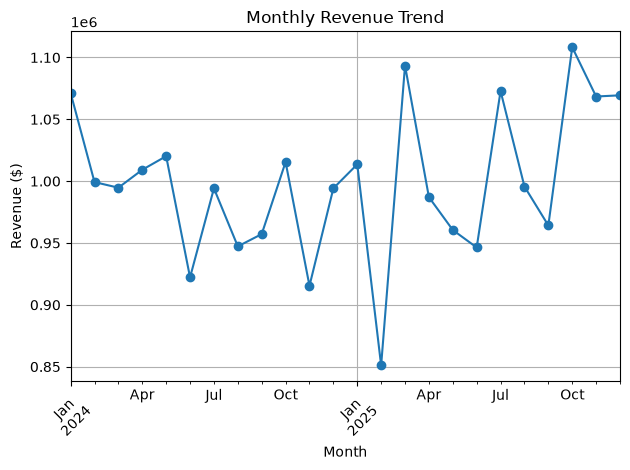

In [16]:
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation

Monthly revenue remains relatively stable across the two-year period, with normal month-to-month fluctuations but no clear long-term trend or strong seasonal pattern.

Revenue reaches its lowest point in February 2025 and its highest point in October 2025.

Because the dataset is synthetically generated without explicit seasonal behavior, these fluctuations should be interpreted as variation in the generated transactions rather than evidence of real-world seasonality.

## Store Performance

We analyze revenue across the five retail stores to determine whether sales are evenly distributed or concentrated in specific locations.

In [17]:
store_revenue = (
    df.groupby("store_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

store_revenue

store_id
S001    7266621.94
S002    6027696.47
S003    4743585.60
S004    3520703.41
S005    2412829.48
Name: total_sales, dtype: float64

In [18]:
store_transactions = (
    df.groupby("store_id")
    .size()
    .sort_values(ascending=False)
)

store_transactions

store_id
S001    15060
S002    12425
S003    10007
S004     7452
S005     5056
dtype: int64

In [19]:
avg_revenue_per_transaction = (
    df.groupby("store_id")["total_sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_revenue_per_transaction

store_id
S002    485.126476
S001    482.511417
S005    477.221021
S003    474.026741
S004    472.450806
Name: total_sales, dtype: float64

### Observation

Total revenue varies substantially across stores, with S001 generating the highest revenue and S005 generating the lowest.

Further analysis shows that this difference is primarily driven by transaction volume. S001 processed 15,060 transactions compared with 5,056 at S005.

After normalizing for transaction volume, average revenue per transaction is relatively consistent across all five stores, ranging from approximately $472 to $485.

This indicates that store revenue differences are primarily associated with the number of transactions processed rather than major differences in transaction value.

## Customer Behavior

We analyze purchasing activity across customers to understand transaction frequency, total customer value, and differences in purchasing behavior.

In [20]:
customer_transactions = (
    df.groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

customer_transactions.head(10)

customer_id
C1145    44
C0210    42
C0135    41
C1618    41
C0296    40
C1149    39
C1947    39
C0742    39
C0212    39
C0530    39
dtype: int64

In [21]:
customer_revenue = (
    df.groupby("customer_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

customer_id
C1154    32764.03
C0899    32633.81
C1676    30889.14
C0965    30513.96
C1108    30064.05
C0819    28743.96
C1927    28484.31
C1855    27459.21
C1609    27359.20
C1056    27194.24
Name: total_sales, dtype: float64

In [22]:
customer_transactions.describe()

count    2000.000000
mean       25.000000
std         5.132657
min        11.000000
25%        21.000000
50%        25.000000
75%        28.000000
max        44.000000
dtype: float64

### Customer Transaction Distribution

We examine the distribution of customer transaction frequency to understand how purchasing activity varies across the customer base.

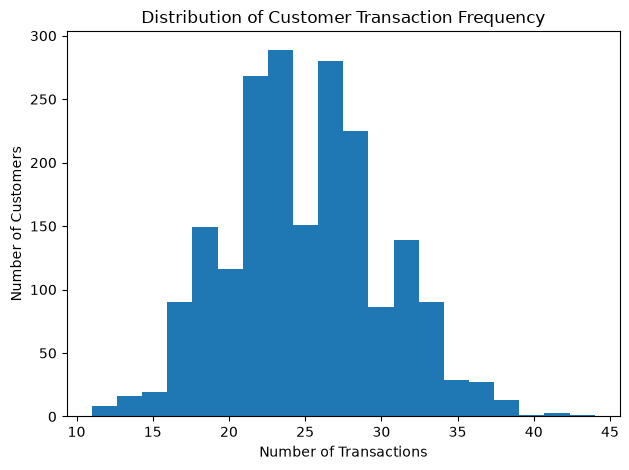

In [23]:
customer_transactions.plot(kind="hist", bins=20)

plt.title("Distribution of Customer Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

### Observation

Customer transaction frequency is concentrated around approximately 20–30 purchases.

The average and median customer both completed 25 transactions, while activity ranges from 11 to 44 transactions.

The distribution shows moderate variation in purchasing frequency, providing a useful foundation for customer segmentation and further behavioral analysis.

## RFM Customer Segmentation

RFM analysis evaluates customer behavior using three measures:

- **Recency:** How recently the customer made a purchase
- **Frequency:** How often the customer made purchases
- **Monetary:** How much revenue the customer generated

These measures can be used to identify differences in customer behavior and support customer segmentation.

In [24]:
latest_sale_date = df["sale_date"].max()

latest_sale_date

Timestamp('2025-12-31 00:00:00')

In [25]:
analysis_date = latest_sale_date + pd.Timedelta(days=1)

analysis_date

Timestamp('2026-01-01 00:00:00')

In [26]:
rfm = (
    df.groupby("customer_id")
    .agg(
        last_purchase=("sale_date", "max"),
        frequency=("sale_id", "count"),
        monetary=("total_sales", "sum")
    )
)

rfm["recency"] = (
    analysis_date - rfm["last_purchase"]
).dt.days

rfm.head()

,last_purchase,frequency,monetary,recency
customer_id,,,,
C0001,2025-11-18,28,12149.29,44
C0002,2025-12-06,25,14889.33,26
C0003,2025-12-05,25,9694.21,27
C0004,2025-11-12,24,7164.35,50
C0005,2025-12-25,25,11209.26,7


In [27]:
rfm_analysis = rfm[
    ["recency", "frequency", "monetary"]
].copy()

rfm_analysis.head()

,recency,frequency,monetary
customer_id,,,
C0001,44,28,12149.29
C0002,26,25,14889.33
C0003,27,25,9694.21
C0004,50,24,7164.35
C0005,7,25,11209.26


In [28]:
rfm_analysis.describe()

,recency,frequency,monetary
count,2000.000000,2000.000000,2000.000000
mean,29.724000,25.000000,11985.718450
std,28.903054,5.132657,5041.891702
min,1.000000,11.000000,1489.630000
25%,9.000000,21.000000,8124.325000
50%,21.000000,25.000000,11384.265000
75%,40.000000,28.000000,15084.132500
max,291.000000,44.000000,32764.030000


### RFM Scoring

Customers are assigned scores from 1 to 4 for Recency, Frequency, and Monetary value.

Higher Frequency and Monetary values receive higher scores, while lower Recency values receive higher scores because recent purchasing activity indicates stronger customer engagement.

In [29]:
rfm_analysis["R_score"] = pd.qcut(
    rfm_analysis["recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

rfm_analysis["F_score"] = pd.qcut(
    rfm_analysis["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

rfm_analysis["M_score"] = pd.qcut(
    rfm_analysis["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

rfm_analysis.head()

,recency,frequency,monetary,R_score,F_score,M_score
customer_id,,,,,,
C0001,44,28,12149.29,1,3,3
C0002,26,25,14889.33,2,2,3
C0003,27,25,9694.21,2,2,2
C0004,50,24,7164.35,1,2,1
C0005,7,25,11209.26,4,2,2


In [30]:
rfm_analysis["RFM_score"] = (
    rfm_analysis["R_score"].astype(int)
    + rfm_analysis["F_score"].astype(int)
    + rfm_analysis["M_score"].astype(int)
)

rfm_analysis.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,
C0001,44,28,12149.29,1,3,3,7
C0002,26,25,14889.33,2,2,3,7
C0003,27,25,9694.21,2,2,2,6
C0004,50,24,7164.35,1,2,1,4
C0005,7,25,11209.26,4,2,2,8


In [31]:
rfm_analysis["RFM_score"].value_counts().sort_index()

RFM_score
3      87
4     145
5     194
6     268
7     281
8     293
9     290
10    215
11    165
12     62
Name: count, dtype: int64

### Customer Segmentation

Customers are grouped into four segments based on their combined RFM score:

- **At Risk (3–5):** Lower overall RFM performance
- **Developing (6–7):** Moderate customer engagement and value
- **Loyal (8–9):** Strong customer engagement and value
- **Champions (10–12):** Highest overall RFM performance

These segments provide a simplified view of customer behavior based on recency, purchase frequency, and monetary value.

In [32]:
def assign_segment(score):
    if score <= 5:
        return "At Risk"
    elif score <= 7:
        return "Developing"
    elif score <= 9:
        return "Loyal"
    else:
        return "Champions"

rfm_analysis["segment"] = (
    rfm_analysis["RFM_score"].apply(assign_segment)
)

rfm_analysis.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
customer_id,,,,,,,,
C0001,44,28,12149.29,1,3,3,7,Developing
C0002,26,25,14889.33,2,2,3,7,Developing
C0003,27,25,9694.21,2,2,2,6,Developing
C0004,50,24,7164.35,1,2,1,4,At Risk
C0005,7,25,11209.26,4,2,2,8,Loyal


In [33]:
segment_counts = rfm_analysis["segment"].value_counts()

segment_counts

segment
Loyal         583
Developing    549
Champions     442
At Risk       426
Name: count, dtype: int64

In [34]:
segment_percentages = (
    rfm_analysis["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

segment_percentages

segment
Loyal         29.2
Developing    27.4
Champions     22.1
At Risk       21.3
Name: proportion, dtype: float64

### Customer Segment Distribution

The distribution of RFM customer segments shows how the customer base is divided according to recency, purchase frequency, and monetary value.

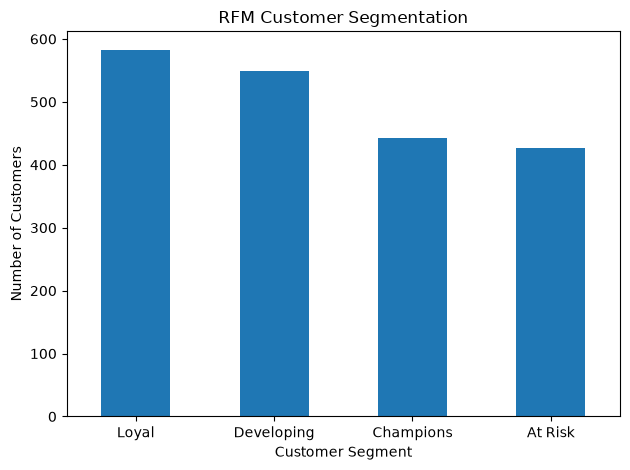

In [36]:
segment_counts.plot(kind="bar")

plt.title("RFM Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Observation

RFM analysis divided the 2,000 customers into four behavioral segments.

- **Loyal:** 583 customers (29.2%)
- **Developing:** 549 customers (27.5%)
- **Champions:** 442 customers (22.1%)
- **At Risk:** 426 customers (21.3%)

The relatively balanced distribution provides distinct customer groups for further analysis. These rule-based RFM segments can also serve as a useful comparison with machine-learning-based customer clustering.